6/23/2026

# v2 — From a Lookup Table to a Linear Head (+ Position Embeddings)

This builds directly on **v1**. Steps 1–7 below (imports, hyperparameters, data, tokenizer, train/val split, batching, loss estimation) are *unchanged* from v1 — copy them straight over.

The real change is in the model (step 8):

1. `token_embedding_table` now maps a token to an `emb_size`-dim vector, instead of directly to `vocab_size` logits.
2. We add a **position embedding** table — the model can now (in principle) tell *where* in the block a token sits. It won't do much yet, since a bigram model has no mechanism to use that extra context — but every block we add from here on (attention, etc.) builds on this same pattern.
3. A `linear_head` projects the embedding back up to `vocab_size` logits.
4. Because position embeddings only go up to `block_size`, `generate` must now crop the context to the last `block_size` tokens before calling the model.

## 1. Imports (same as v1)

In [1]:
import torch
import torch.nn as nn
from torch.nn import functional as F

## 2. Hyperparameters

Same as v1, plus one new one: `emb_size` — the dimensionality of the token/position embedding vectors. This is what decouples the embedding size from `vocab_size`.

*this will let us increase the complexity of the model*

In [2]:
# emb_size = 32        # NEW: embedding size for each token
# batch_size = 32      # how many independent sequences will we process in parallel?
# block_size = 8       # what is the maximum context length for predictions?
# max_iters = 10000    # maximum number of iterations for training
# eval_interval = 500  # interval for evaluating the model
# learning_rate = 1e-3 # learning rate for training
# device = 'cuda' if torch.cuda.is_available() else 'cpu'
# eval_iters = 200     # number of iterations for evaluation
# seed = 42            # seed for reproducibility

# torch.manual_seed(seed)

In [3]:
# Sabine's version of the above block that does hardware detection (that way on Mac it uses GPU if available rather than CPU default)
# Detect best available device (CUDA>MPS>CPU) and set DataLoader workers accordingly
import os

emb_size = 32        # NEW: embedding size for each token
batch_size = 32      # how many independent sequences will we process in parallel?
block_size = 8       # what is the maximum context length for predictions?
max_iters = 10000    # maximum number of iterations for training
eval_interval = 500  # interval for evaluating the model
learning_rate = 1e-3 # learning rate for training
eval_iters = 200     # number of iterations for evaluation
seed = 42            # seed for reproducibility

if torch.cuda.is_available():
    device = torch.device("cuda")
    total_cores = os.cpu_count()
    NUM_WORKERS = min(8, max(1, total_cores - 2))

elif torch.backends.mps.is_available():
    device = torch.device("mps")
    NUM_WORKERS = 0  # MPS + multiprocessing can hang

else:
    device = torch.device("cpu")
    NUM_WORKERS = 0

print(f"Using device: {device}")
torch.manual_seed(seed)

Using device: cuda


## 3. Load the dataset

In [4]:
with open('./data/harry_potter.txt', encoding='utf-8') as f:
    text = f.read()

print(f"length of dataset in characters: {len(text)}")
print(text[:500])

length of dataset in characters: 5991293
THE BOY WHO LIVED Mr and Mrs Dursley of number four Privet Drive were proud to say that they were perfectly normal thank you very much .They were the last people youd expect to be involved in anything strange or mysterious because they just didnt hold with such nonsense .Mr Dursley was the director of a firm called Grunnings which made drills .He was a big beefy man with hardly any neck although he did have a very large mustache .Mrs Dursley was thin and blonde and had nearly twice the usual amo


## 4. Tokenization: characters as tokens

In [5]:
chars = sorted(list(set(text)))
vocab_size = len(chars)
print(''.join(chars))
print(vocab_size)

 !.0123456789?ABCDEFGHIJKLMNOPQRSTUVWXYZabcdefghijklmnopqrstuvwxyz~‘•■□
71


In [6]:
stoi = { ch:i for i,ch in enumerate(chars) }
itos = { i:ch for i,ch in enumerate(chars) }
encode = lambda s: [stoi[c] for c in s] # encoder: take a string, output a list of integers
decode = lambda l: ''.join([itos[i] for i in l]) # decoder: take a list of integers, output a string

print(encode("Hello there!"))
print(decode(encode("Hello there!")))

[21, 44, 51, 51, 54, 0, 59, 47, 44, 57, 44, 1]
Hello there!


## 5. Train / validation split

In [7]:
data = torch.tensor(encode(text), dtype=torch.long)
n = int(0.9*len(data)) # first 90% will be train, rest val
train_data = data[:n]
val_data = data[n:]

print(data.shape, data.dtype)
print(data[:100])

torch.Size([5991293]) torch.int64
tensor([33, 21, 18,  0, 15, 28, 38,  0, 36, 21, 28,  0, 25, 22, 35, 18, 17,  0,
        26, 57,  0, 40, 53, 43,  0, 26, 57, 58,  0, 17, 60, 57, 58, 51, 44, 64,
         0, 54, 45,  0, 53, 60, 52, 41, 44, 57,  0, 45, 54, 60, 57,  0, 29, 57,
        48, 61, 44, 59,  0, 17, 57, 48, 61, 44,  0, 62, 44, 57, 44,  0, 55, 57,
        54, 60, 43,  0, 59, 54,  0, 58, 40, 64,  0, 59, 47, 40, 59,  0, 59, 47,
        44, 64,  0, 62, 44, 57, 44,  0, 55, 44])


## 6. Batching

In [8]:
def get_batch(split):
    # generate a small batch of data of inputs x and targets y
    data = train_data if split == 'train' else val_data
    ix = torch.randint(len(data) - block_size, (batch_size,))
    x = torch.stack([data[i:i+block_size] for i in ix])
    y = torch.stack([data[i+1:i+block_size+1] for i in ix])
    x, y = x.to(device), y.to(device)
    return x, y

In [9]:
xb, yb = get_batch('train')
print('inputs:')
print(xb.shape)
print(xb)
print('targets:')
print(yb.shape)
print(yb)

inputs:
torch.Size([32, 8])
tensor([[54, 60, 57,  0, 52, 54, 59, 47],
        [ 0, 52, 40, 64,  0, 58, 59, 48],
        [44, 58, 58, 54, 57,  0, 15, 51],
        [58, 40, 48, 43,  0, 19, 44, 44],
        [58, 59, 60, 43, 44, 53, 59, 58],
        [57, 40, 48, 59,  0, 58, 62, 60],
        [ 0, 40, 42, 42, 54, 52, 55, 40],
        [ 0, 40, 58,  0, 47, 44,  0, 43],
        [40, 50, 48, 53, 46,  0, 54, 60],
        [48, 58,  0, 48, 53,  0, 45, 40],
        [51, 40, 55,  0, 55, 60, 57, 57],
        [59,  0, 47, 48, 58,  0, 55, 54],
        [57, 44,  0, 47, 40, 43,  0, 59],
        [21, 40, 57, 57, 64,  0,  2, 27],
        [41, 51, 48, 53, 50, 48, 53, 46],
        [ 0, 41, 54, 64,  0, 47, 44, 58],
        [47, 54,  0, 62, 40, 58,  0, 58],
        [44,  0, 58, 52, 48, 57, 50, 44],
        [ 0, 59, 47, 44, 64,  0, 55, 40],
        [40, 57, 57, 64,  0, 51, 40, 60],
        [40, 51, 51, 64,  0, 21, 40, 46],
        [59,  0, 52, 44,  0, 52, 54, 58],
        [47, 40, 61, 44,  0, 43, 57, 40],
      

## 7. Estimating loss

In [10]:
@torch.no_grad()
def estimate_loss():
    out = {}
    model.eval()
    for split in ['train', 'val']:
        losses = torch.zeros(eval_iters)
        for k in range(eval_iters):
            X, Y = get_batch(split)
            logits, loss = model(X, Y)
            losses[k] = loss.item()
        out[split] = losses.mean()
    model.train()
    return out

## 8. The model — what's new

In v1, `token_embedding_table` mapped a token directly to its `vocab_size` logits. Now we decouple the embedding dimension from the vocabulary size:

- `token_embedding_table`: token id → `emb_size`-dim vector *(changed: used to go straight to `vocab_size`)*
- `position_embedding_table` **(new)**: position id → `emb_size`-dim vector, so the model has a notion of *where* a token sits in the block
- `linear_head` **(new)**: projects the summed token + position embedding back up to `vocab_size` logits
- in `generate`, the context must now be cropped to `block_size` **(new)**, since `position_embedding_table` only has `block_size` rows

**In class:** fill in the parts marked **NEW** below — everything else carries over unchanged from v1.

In [11]:
# bigram model with a linear head and position embeddings
class BigramLanguageModel(nn.Module):

    def __init__(self, vocab_size, emb_size):
        super().__init__()
        # NEW: each token now maps to an emb_size-dim vector, not directly to vocab_size logits
            # now instead of predicting one of the 71 chars from the 71 chars, 
            # we are learning an embedding a 32 dim representation for every character
        self.token_embedding_table = nn.Embedding(vocab_size, emb_size) # this is a tensor of 71x32 (so C dimension here is 32)

        # NEW: position id (0..block_size-1) -> emb_size-dim vector
        # we'll make real use of this once we add attention
        # instead of something like sineusoidal, we'll use another embedding layer to do positional embedding
        self.position_embedding_table = nn.Embedding(block_size, emb_size) 
            # here, we only care about the position of the embedding within the block
                # we'd get character info from the token embedding table
                # this would improve as block size increases

        # NEW: projects the emb_size-dim vector back up to vocab_size logits
        self.linear_head = nn.Linear(emb_size, vocab_size) # nn.Linear takes input dim and output dim (here its (32, 71))
            # we add this linear layer to take the 32 dim representation and convert it back to the size of the vocabulary
            # we manage our dimensions so they match each other; keep dimensions in mind as a way to make sense of what we are doing

    def forward(self, idx, targets=None):
        # forward function is how we want our input to propogate through the model/how it should process our information forward

        B, T = idx.shape

        # idx and targets are both (B,T) tensor of integers
        # NEW: look up token embeddings -> (B,T,emb_size)
        tok_emb = self.token_embedding_table(idx) # (32, 8, 32)

        # C is the embedding size, T is the sequence length (aka the block size), B is the batch size
        # NEW: look up position embeddings for positions 0..T-1 -> (T,emb_size)
        pos_emb = self.position_embedding_table(torch.arange(T, device=idx.device)) # (8, 32) # arange converts T (scalar) into a tensor as required by torch

        # NEW: combine token identity and position -> (B,T,emb_size)
        x = tok_emb + pos_emb # (32, 8, 32)
            # so our input, x, is now the embeddings we got from the token and the embeddings from the position

        # NEW: project up to vocab_size logits -> (B,T,vocab_size)
            # take input, pass through linear head to convert from embedding size back to vocabulary size
        logits = self.linear_head(x) # (32, 8, 71)

        if targets is None:
            loss = None
        else:
            B, T, C = logits.shape
            logits = logits.view(B*T, C) # reshaping with view
            targets = targets.view(B*T)
            loss = F.cross_entropy(logits, targets)

        return logits, loss
# note we aren't changing input or output, just adding complexity within model

    def generate(self, idx, max_new_tokens):
        # idx is (B, T) array of indices in the current context
        for _ in range(max_new_tokens):
            # NEW: crop idx to the last block_size tokens
            # (position_embedding_table only has block_size rows!)
            idx_cond = idx[:, -block_size:]

            # get the predictions
            logits, loss = self(idx_cond)
            # focus only on the last time step
            logits = logits[:, -1, :] # becomes (B, C)
            # apply softmax to get probabilities
            probs = F.softmax(logits, dim=-1) # (B, C)
            # sample from the distribution
            idx_next = torch.multinomial(probs, num_samples=1) # (B, 1)
            # append sampled index to the running sequence
            idx = torch.cat((idx, idx_next), dim=1) # (B, T+1)
        return idx

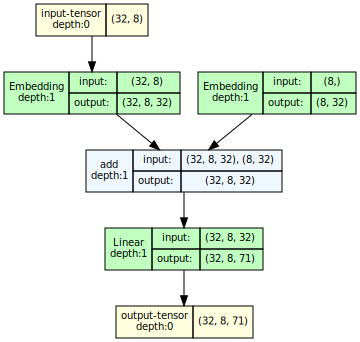

In [12]:
from torchview import draw_graph

model_graph = draw_graph(
    BigramLanguageModel(vocab_size, emb_size),
    input_size=(batch_size, block_size),
    dtypes=[torch.long]
)
model_graph.visual_graph

In [13]:
# look at the dimensions
BigramLanguageModel(vocab_size, emb_size)

BigramLanguageModel(
  (token_embedding_table): Embedding(71, 32)
  (position_embedding_table): Embedding(8, 32)
  (linear_head): Linear(in_features=32, out_features=71, bias=True)
)

## 9. Sanity check: untrained generation

Note the model now also takes `emb_size` when constructed.

In [14]:
model = BigramLanguageModel(vocab_size, emb_size)
model = model.to(device)
# print the number of parameters in the model
print(sum(p.numel() for p in model.parameters())/1e6, 'M parameters')

context = torch.zeros((1, 1), dtype=torch.long, device=device)
print(decode(model.generate(context, max_new_tokens=200)[0].tolist()))

0.004871 M parameters
 cE6GmE68QIWayCj2cmS4~E■A‘yFTccWQ68•p6TT3Wo7wSFIWtzGiYpJOWWO40?RWwJK6ouvBrRa~HJHSO0jp?f~QoOF?iXOtyVFKbnD?8hMJdcI yQc0ODHWGlFhMDBEhMiMor aWgSRcilTZyOGEct3aYzSUEforWE7hXObSp8i4G~BTpiMOcE■T7v4NPaQtNnDgubd


## 10. Training the model

In [15]:
# create a PyTorch optimizer
optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate)

for iter in range(max_iters):

    # every once in a while evaluate the loss on train and val sets
    if iter % eval_interval == 0 or iter == max_iters - 1:
        losses = estimate_loss()
        print(f"step {iter}: train loss {losses['train']:.4f}, val loss {losses['val']:.4f}")

    # sample a batch of data
    xb, yb = get_batch('train')

    # evaluate the loss
    logits, loss = model(xb, yb)
    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    optimizer.step()

step 0: train loss 4.5946, val loss 4.6071
step 500: train loss 2.5435, val loss 2.5375
step 1000: train loss 2.4699, val loss 2.4493
step 1500: train loss 2.4494, val loss 2.4114
step 2000: train loss 2.4152, val loss 2.3983
step 2500: train loss 2.4135, val loss 2.3899
step 3000: train loss 2.4048, val loss 2.3824
step 3500: train loss 2.3969, val loss 2.3921
step 4000: train loss 2.3958, val loss 2.3768
step 4500: train loss 2.3968, val loss 2.3777
step 5000: train loss 2.3953, val loss 2.3778
step 5500: train loss 2.3993, val loss 2.3770
step 6000: train loss 2.3897, val loss 2.3643
step 6500: train loss 2.3872, val loss 2.3720
step 7000: train loss 2.3896, val loss 2.3719
step 7500: train loss 2.3905, val loss 2.3684
step 8000: train loss 2.3819, val loss 2.3699
step 8500: train loss 2.3947, val loss 2.3763
step 9000: train loss 2.3804, val loss 2.3706
step 9500: train loss 2.3892, val loss 2.3648
step 9999: train loss 2.3765, val loss 2.3693


*notice we start, expectedly, at the same loss as the previous version. but the loss gets smaller faster here*

## 11. Generate text from the trained model

In [16]:
print('''\n##########################################
# Let's generate some Harry Potter text! #
##########################################''')
context = torch.zeros((1, 1), dtype=torch.long, device=device)
print(decode(model.generate(context, max_new_tokens=1000)[0].tolist()))


##########################################
# Let's generate some Harry Potter text! #
##########################################
 med apllouly .Yoprimildd rellin thot ikllouge m hele s ke Ang mer .Dun toud sitopindiluit my ce t rel Flid thakeld .Seanckoupr ored d s mefirnd toris ty Han wares f peched Mavaime d rr he andne a metiveemilme d arunoomorar rerily thet Pen olered hing Herrmean t teangl who .FAnrd s ay oris t oy shag burree ntthaul agtacat .Hondolet Cul w ooryetas aiatlid Rory .Wes STOw acoulerd d m Po uteRounaumersl g wewat loot baggaleau .Yo irm aninid a hins acars yonm ok n .Fbe we tl helly athethidinol pe ber thattean re llay s nentou .He ce sten wely gis He e ok m Im revind e d w wesspucharedin tooollid ofedlys furid plaby woped hit ?don ar osed t ?sofun s we d d y Po me berry Hareno waind t gease ns thiboffe d blin s s s tor .Won s ofarreas coulow ..Theet formerlsteyple ind I amy mp ?BAmismmby Emeve Snonthefolly lliee .Mine de g t t tsth Helystotay bupothelf toriclondg 

*still bad, but better than v1*